In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import get_data
import matplotlib.pyplot as plt
import population_activity as pop
import helper_functions as hf
import analysis
import plots
import statistics_test as st

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path
OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,   
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def analyze_data_common(datapath, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                        transients=False, dim_red=False, max_dim=4, standardize='stand'):
    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context

    analysis_func, context_func = get_analysis_function(analysis_type)

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    hists = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference=reference, maps=maps, 
                                                 reference_type='no_reference', hist='hist', transients=transients, 
                                                 dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g = apply_analysis(analysis_func, hists)
    hists_2 = analysis.sort_maps_from_reference_AK(datapath, 'Context2', reference=reference, maps=maps, 
                                                   reference_type='no_reference', hist='hist', transients=transients,
                                                     dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g_2 = apply_analysis(analysis_func, hists_2)

    global_seeds = [1,2,3,4,5]
    simu_g_list = []
    for seed in global_seeds:
        simu_drift = analysis.simulate_drift(datapath, session='0', Context='Context1', days=len(maps)+1, drift_type='circular', 
                                             dim_red=dim_red, standardize=standardize, odd_even=True, global_seed=seed, 
                                             active_days=[reference]+maps, remove_day_inactive=True,
                                             max_remap_prob=0.3, amplitude_drift_prob=0.3, amplitude_change_scale=0.5)
        simu_g = apply_analysis(analysis_func, simu_drift['maps'])
        simu_g_list.append(simu_g)
    simu_g_array = np.array(simu_g_list)
    simu_g = np.mean(simu_g_array, axis=0)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=maps, 
                                                                                  transients=transients, dim_red=dim_red, standardize=standardize, 
                                                                                  remove_day_inactive=False)
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)
    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context2', maps=maps, transients=transients, dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g_odd_even2 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':              
        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context1', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                            standardize=standardize, remove_day_inactive=False)
        shuff1_con2, shuff2_con2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context2', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                                      standardize=standardize, remove_day_inactive=False)
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])
        g_shuff2 = apply_analysis(context_func, [shuff1_con2], [shuff2_con2])
        
        g = (g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
        g_2 = (g_2 - np.mean(g_odd_even2)) / (np.mean(g_shuff2) - np.mean(g_odd_even2))
        simu_g = (simu_g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
    else:
        g = g-g_odd_even1
        g_2 = g_2-g_odd_even2
        simu_g = simu_g-g_odd_even1

    if compute_day11_12:
        hists_day11 = [h for h, m in zip(hists, maps) if m == '17']
        hists_day12 = [h for h, m in zip(hists, maps) if m == '19']
        hists_2_day12 = [h for h, m in zip(hists_2, maps) if m == '19']

        g_day11_12_context1 = apply_analysis(context_func, hists_day11, hists_day12)
        g_day12_contexts = apply_analysis(context_func, hists_day12, hists_2_day12)

        if analysis_type == 'population_geometry':
            hist_odd_1, hist_even_1 = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=['12'], 
                                                                                          transients=transients, dim_red=dim_red, 
                                                                                          standardize=standardize, remove_day_inactive=False)
            g_odd_even_1 = apply_analysis(context_func, hist_odd_1, hist_even_1)
            g_shuff_11_12 = apply_analysis(context_func, [shuff2], [shuff2_con2])

            g_day12_contexts_norm = (g_day12_contexts - g_odd_even_1) / (np.mean(g_shuff_11_12) - g_odd_even_1)
            g_day11_12_context1_norm = (g_day11_12_context1 - g_odd_even_1) / (np.mean(g_shuff_11_12) - g_odd_even_1)
        else:
            g_day12_contexts_norm = g_day12_contexts
            g_day11_12_context1_norm = g_day11_12_context1

        return g, g_2, simu_g, g_day12_contexts_norm, g_day11_12_context1_norm
    else:
        return g, g_2, simu_g


def collect_data(datapaths, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                 transients=False, dim_red=False, max_dim=4, standardize='stand'):
    all_data = []
    for datapath in datapaths:
        data = analyze_data_common(datapath, reference, maps, analysis_type, method=method, compute_day11_12=compute_day11_12, 
                                   transients=transients, dim_red=dim_red, max_dim=max_dim, standardize=standardize)
        all_data.append(data)
    return all_data

if __name__ == "__main__":
    datapaths = ['D:/Antje_CA1/data_sig/170.h5', 'D:/Antje_CA1/data_sig/51004.h5', 'D:/Antje_CA1/data_sig/51007.h5',
                  'D:/Antje_CA1/data_sig/63.h5', 'D:/Antje_CA1/data_sig/64.h5', 'D:/Antje_CA1/data_sig/65.h5']
    transients = False
    dim_red = False
    max_dim = 4

    reference = '0'
    maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
    forward_data_pop_geometry_angles = collect_data(datapaths, reference, maps, 'population_geometry', method='angles', 
                                                    compute_day11_12=True, transients=transients, dim_red=dim_red, standardize='stand')

    reference_reverse = '19'
    maps_reverse =  ['17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]
    reverse_data_pop_geometry_angles = collect_data(datapaths, reference_reverse, maps_reverse, 'population_geometry', 
                                                    method='angles', compute_day11_12=False, transients=transients, dim_red=dim_red,  standardize='stand')


C:\Users\Ole\AppData\Local\Temp\ipykernel_19312\2142609500.py:12: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


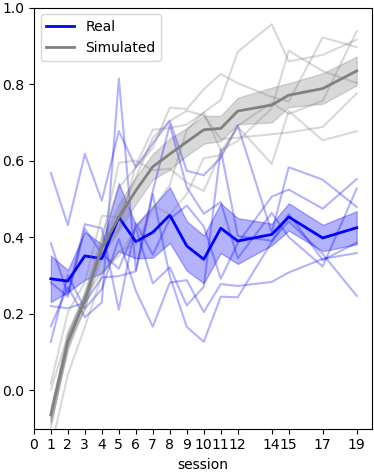

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,4.038007,15,75,0.269200,33.433048,4.244521e-27,2.363429e-07,0.621616,0.218161
1,condition,1.198404,1,5,1.198404,15.441219,1.107551e-02,1.107551e-02,0.327757,1.000000
2,time * condition,2.235321,15,75,0.149021,17.639676,8.823681e-19,3.325580e-05,0.476280,0.201289


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,6.2010,0.0016,0.0255,*,2.5315,Cohen's d,0.2915,-0.0637,0.3552,0.1403,6,True,0.5095
1,T2,C1,C2,t-test,4.3607,0.0073,0.1166,,1.7803,Cohen's d,0.2855,0.1281,0.1575,0.0885,6,True,0.8988
2,T3,C1,C2,t-test,1.8151,0.1292,1.0000,,0.7410,Cohen's d,0.3513,0.2347,0.1166,0.1573,6,True,0.4090
3,T4,C1,C2,t-test,-0.9122,0.4035,1.0000,,-0.3724,Cohen's d,0.3442,0.3722,-0.0280,0.0753,6,True,0.2727
4,T5,C1,C2,t-test,0.0028,0.9978,1.0000,,0.0012,Cohen's d,0.4524,0.4521,0.0003,0.2852,6,True,0.9302
5,T6,C1,C2,t-test,-3.4416,0.0184,0.2945,,-1.4050,Cohen's d,0.3885,0.5216,-0.1331,0.0948,6,True,0.8977
6,T7,C1,C2,t-test,-2.4408,0.0586,0.9375,,-0.9965,Cohen's d,0.4130,0.5843,-0.1713,0.1719,6,True,0.5765
7,T8,C1,C2,t-test,-1.8698,0.1204,1.0000,,-0.7633,Cohen's d,0.4578,0.6172,-0.1594,0.2088,6,True,0.6059
8,T9,C1,C2,t-test,-3.3641,0.0200,0.3203,,-1.3734,Cohen's d,0.3772,0.6492,-0.2720,0.1981,6,True,0.1487
9,T10,C1,C2,t-test,-4.5957,0.0059,0.0938,,-1.8762,Cohen's d,0.3423,0.6807,-0.3384,0.1803,6,True,0.9739


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.253710,15,0.016914,1.475306,0.136605,0.122709,0.208599
1,Error,0.859855,75,0.011465,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,6.019618,15,0.401308,79.699261,9.419049e-40,0.903341,0.240053
1,Error,0.377646,75,0.005035,NaN,NaN,NaN,NaN


C:\Users\Ole\AppData\Local\Temp\ipykernel_19312\2142609500.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


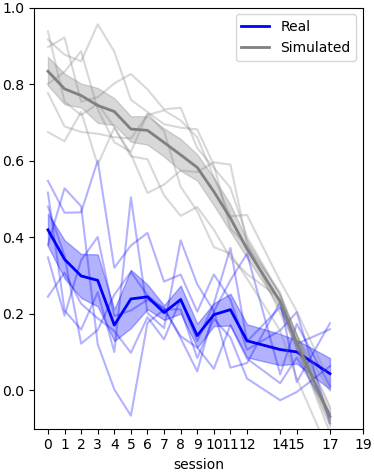

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,5.393652,15,75,0.359577,40.187609,1.126091e-29,5.303665e-09,0.746510,0.256381
1,condition,5.310821,1,5,5.310821,68.025115,4.271197e-04,4.271197e-04,0.743570,1.000000
2,time * condition,1.520490,15,75,0.101366,11.686706,4.211598e-14,1.748213e-04,0.453607,0.221557


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,-9.7991,0.0002,0.0030,**,-4.0005,Cohen's d,0.4195,0.8336,-0.4142,0.1035,6,True,0.4673
1,T2,C1,C2,t-test,-8.3618,0.0004,0.0064,**,-3.4137,Cohen's d,0.3425,0.7875,-0.4450,0.1304,6,True,0.6812
2,T3,C1,C2,t-test,-6.5663,0.0012,0.0197,*,-2.6807,Cohen's d,0.2990,0.7702,-0.4713,0.1758,6,True,0.6395
3,T4,C1,C2,t-test,-4.3240,0.0075,0.1207,,-1.7653,Cohen's d,0.2874,0.7441,-0.4567,0.2587,6,True,0.6363
4,T5,C1,C2,t-test,-7.9246,0.0005,0.0082,**,-3.2352,Cohen's d,0.1705,0.7283,-0.5578,0.1724,6,True,0.1111
5,T6,C1,C2,t-test,-4.3425,0.0074,0.1186,,-1.7728,Cohen's d,0.2389,0.6826,-0.4437,0.2503,6,True,0.9521
6,T7,C1,C2,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.2444,0.6791,-0.4347,0.1754,6,False,0.0130
7,T8,C1,C2,t-test,-7.8739,0.0005,0.0085,**,-3.2145,Cohen's d,0.2032,0.6475,-0.4443,0.1382,6,True,0.2368
8,T9,C1,C2,t-test,-5.6102,0.0025,0.0398,*,-2.2903,Cohen's d,0.2373,0.6152,-0.3779,0.1650,6,True,0.8922
9,T10,C1,C2,t-test,-7.3436,0.0007,0.0118,*,-2.9980,Cohen's d,0.1431,0.5822,-0.4392,0.1465,6,True,0.5797


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.846348,15,0.056423,4.50341,0.000006,0.421501,0.249999
1,Error,0.939675,75,0.012529,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,6.067794,15,0.404520,79.441062,1.054880e-39,0.900572,0.238559
1,Error,0.381905,75,0.005092,NaN,NaN,NaN,NaN


In [ ]:
# Forward: real vs simulated
novel = np.vstack([data[1] for data in forward_data_pop_geometry_angles])
simu = np.vstack([data[2] for data in forward_data_pop_geometry_angles])

print_large('\n' + '='*50)
print_large('Forward: Real vs Simulated')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([novel, simu], maps, directions=[True, True], 
                           colors=['b', 'gray'], labels=['Real', 'Simulated'], 
                           plot_individual=True, ylim=[-0.1, 1], ax=ax)
fig.tight_layout()
fig.savefig(OUT / "novel_forward_real_vs_sim.eps", format="eps")
plt.show()

print_large('\nTWO-WAY REPEATED ANOVA: Real vs Simulated')
anova = st.repeated_measures_anova_general([novel, simu])
display(anova[0])
display(anova[1])

print_large('RM ANOVA: Real (forward)')
display(st.repeated_measures_anova_single_condition(novel))
print_large('RM ANOVA: Simulated (forward)')
display(st.repeated_measures_anova_single_condition(simu))


# Reverse: real vs simulated
novel_rev = np.vstack([data[1] for data in reverse_data_pop_geometry_angles])[:, ::-1]
simu_rev = np.vstack([data[2] for data in reverse_data_pop_geometry_angles])[:, ::-1]

print_large('\n' + '='*50)
print_large('Reverse: Real vs Simulated')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([novel_rev, simu_rev], maps, directions=[False, False], 
                           colors=['b', 'gray'], labels=['Real', 'Simulated'], 
                           plot_individual=True, ylim=[-0.1, 1], ax=ax)
fig.tight_layout()
fig.savefig(OUT / "novel_reverse_real_vs_sim.eps", format="eps")
plt.show()

print_large('\nTWO-WAY REPEATED ANOVA: Real vs Simulated')
anova = st.repeated_measures_anova_general([novel_rev, simu_rev])
display(anova[0])
display(anova[1])

print_large('RM ANOVA: Real (reverse)')
display(st.repeated_measures_anova_single_condition(novel_rev))
print_large('RM ANOVA: Simulated (reverse)')
display(st.repeated_measures_anova_single_condition(simu_rev))